In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.6 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.6 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.6 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.6 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.6 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.6 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.6 MB 1.9 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.6 MB 1.9 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.6 MB 1.9 MB/s eta 0:00:03
   -------------------- ---------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df = pd.read_csv('AirPassengers.csv')
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [11]:
df.info

<bound method DataFrame.info of        Month  #Passengers
0    1949-01          112
1    1949-02          118
2    1949-03          132
3    1949-04          129
4    1949-05          121
..       ...          ...
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432

[144 rows x 2 columns]>

In [12]:
df.columns = df.columns.str.strip()
df.columns

Index(['Month', '#Passengers'], dtype='object')

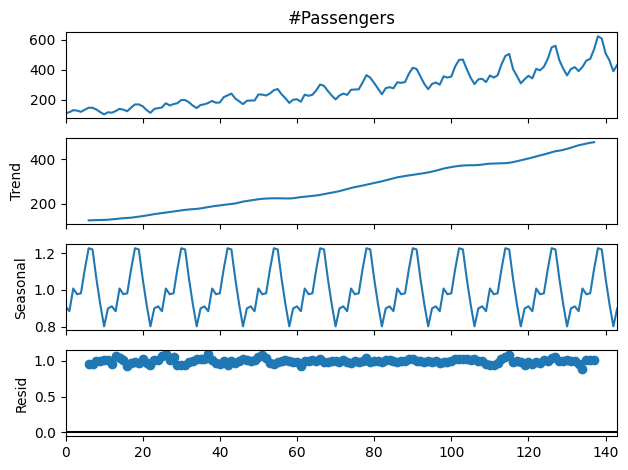

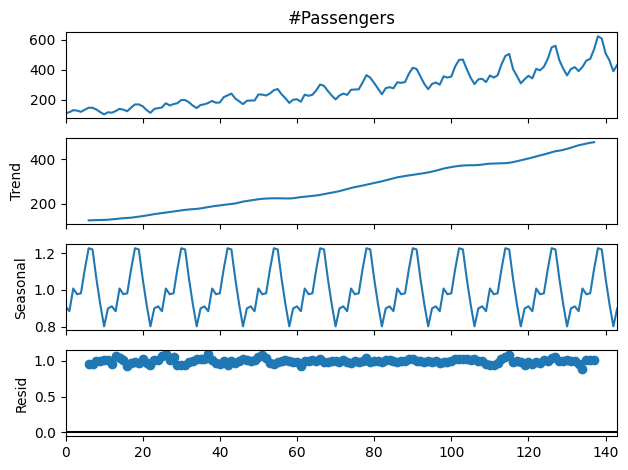

In [14]:
result = seasonal_decompose(df['#Passengers'], model='multiplicative',  period=12)
result.plot()

In [17]:
%pip install pmdarima
from pmdarima.arima import auto_arima
import warnings
warnings.filterwarnings('ignore')

stepwise_fit = auto_arima(df['#Passengers'], start_p=1, start_q=1, max_p=3, max_q=3, m=12, start_P=0, seasonal = True, d=None, D=1, trace=True
                         , error_action = 'ignore', suppress_warnings = True, stepwise = True)

stepwise_fit.summary()

Note: you may need to restart the kernel to use updated packages.
Performing stepwise search to minimize aic



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.24 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.12 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.03 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.20 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.63 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.21 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.19 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.34 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.31 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.27 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.08 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.28 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1020.327, Time=0.31 sec
 ARIM

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Sun, 05 Jul 2026   AIC                           1019.178
Time:                                     15:44:32   BIC                           1030.679
Sample:                                          0   HQIC                          1023.851
                                             - 144                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""